# 03 — L'espace social alimentaire (Analyse des Correspondances Multiples)

L'**ACM** (Analyse des Correspondances Multiples) projette dans un plan les individus et
les modalités de réponse, de sorte que des habitudes qui « vont ensemble » se retrouvent
proches. C'est l'outil de la sociologie de la consommation (Bourdieu) : il révèle les
**oppositions structurantes** dans la manière de manger.

On construit l'espace à partir des **fréquences de consommation** (variables actives),
puis on y projette l'âge, le diplôme et le Score Santé (variables illustratives) pour voir
comment ils s'y inscrivent.

## 1. Préparation et variables actives

Les variables actives sont les huit fréquences de consommation. Les valeurs manquantes
sont traitées comme une modalité à part entière (« Non répondu »), comme dans
l'application.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import prince
from scipy.stats import spearmanr
from IPython.display import display, Markdown

from utils.data_loader import load_data, clean_data

sns.set_theme(style="whitegrid", palette="muted")
df = clean_data(load_data())

ACTIVES = ["C_leg", "C_frui", "C_fec", "C_lait", "C_viaB", "C_viaR", "C_poi", "C_indu"]
FULL = {"C_leg": "Légumes", "C_frui": "Fruits", "C_fec": "Féculents", "C_lait": "Laitiers",
        "C_viaB": "Viande blanche", "C_viaR": "Viande rouge", "C_poi": "Poisson", "C_indu": "Industriels"}
SHORT = {"C_leg": "Lég", "C_frui": "Fru", "C_fec": "Féc", "C_lait": "Lait",
         "C_viaB": "ViaB", "C_viaR": "ViaR", "C_poi": "Poi", "C_indu": "Indu"}
FREQ = {"Jamais": "0", "Très rarement": "TR", "1 x par semaine": "1/sem", "3 x par semaine": "3/sem",
        "5 x par semaine": "5/sem", "1 x par jour": "1/j", "A tous les repas": "++", "Non répondu": "NR"}

X = df[ACTIVES].fillna("Non répondu")
K = len(ACTIVES)
print(f"{X.shape[0]} individus × {K} variables actives")

1681 individus × 8 variables actives


## 2. Ajustement du modèle et inertie brute

On ajuste l'ACM sur cinq axes et on lit la part d'inertie (variance) portée par chacun.

In [2]:
mca = prince.MCA(n_components=5, n_iter=10, random_state=42).fit(X)
display(Markdown(mca.eigenvalues_summary.to_markdown()))

|   component |   eigenvalue | % of variance   | % of variance (cumulative)   |
|------------:|-------------:|:----------------|:-----------------------------|
|           0 |        0.292 | 4.86%           | 4.86%                        |
|           1 |        0.267 | 4.44%           | 9.30%                        |
|           2 |        0.243 | 4.04%           | 13.34%                       |
|           3 |        0.222 | 3.70%           | 17.04%                       |
|           4 |        0.202 | 3.37%           | 20.41%                       |

Les pourcentages bruts paraissent dérisoires (4,9 % pour le premier axe). C'est un
**artefact bien connu de l'ACM** : le codage disjonctif gonfle artificiellement le nombre
de dimensions et écrase mécaniquement les pourcentages. Les comparer à ceux d'une ACP
serait une erreur — il faut les **corriger**.

## 3. Correction de Benzécri

La correction de Benzécri ne retient que les axes dont la valeur propre dépasse 1/K et
recalcule des pourcentages d'inertie réalistes.

| Axe   |   % brut |   % Benzécri |   % Benzécri cumulé |
|:------|---------:|-------------:|--------------------:|
| Axe 1 |     4.86 |         36.1 |                36.1 |
| Axe 2 |     4.44 |         26.1 |                62.1 |
| Axe 3 |     4.04 |         18   |                80.1 |
| Axe 4 |     3.7  |         12.2 |                92.3 |
| Axe 5 |     3.37 |          7.7 |               100   |

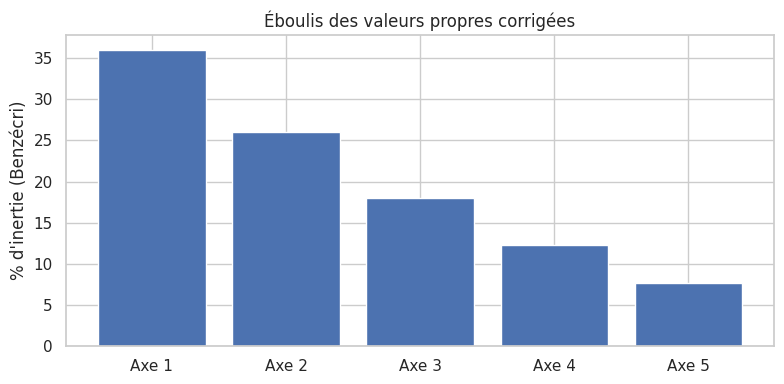

In [3]:
eig = mca.eigenvalues_
thr = 1 / K
ben = np.array([((K / (K - 1)) * (l - thr)) ** 2 if l > thr else 0 for l in eig])
ben_pct = ben / ben.sum() * 100
bz = pd.DataFrame({
    "Axe": [f"Axe {i+1}" for i in range(len(eig))],
    "% brut": np.round(mca.percentage_of_variance_, 2),
    "% Benzécri": np.round(ben_pct, 1),
    "% Benzécri cumulé": np.round(np.cumsum(ben_pct), 1),
})
display(Markdown(bz.to_markdown(index=False)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([f"Axe {i+1}" for i in range(len(eig))], ben_pct, color="#4C72B0")
ax.set_ylabel("% d'inertie (Benzécri)"); ax.set_title("Éboulis des valeurs propres corrigées")
fig.tight_layout()

Après correction, le **plan 1-2 capte environ 62 % de l'inertie** (36 % + 26 %) : il est
largement suffisant pour une lecture en deux dimensions. On peut interpréter les deux
premiers axes en confiance.

## 4. Le plan des modalités

Chaque point est une réponse possible (ex. « Viande rouge = Jamais »). Les modalités
proches sont souvent choisies par les mêmes personnes.

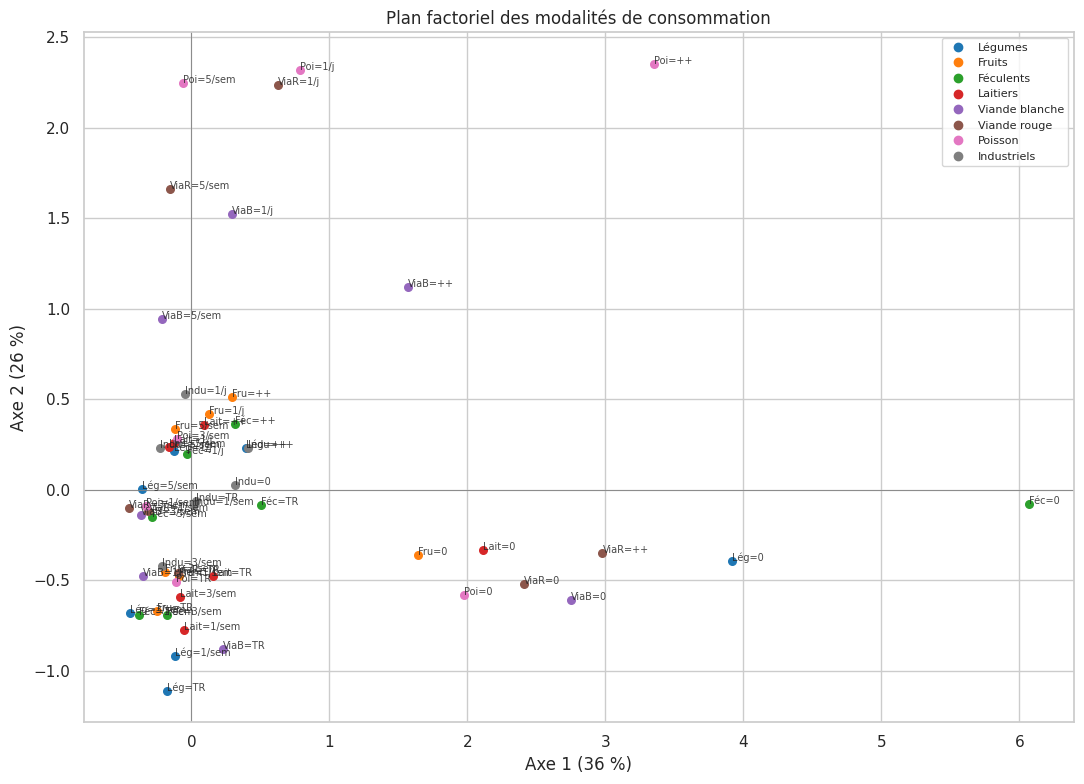

In [4]:
coords = mca.column_coordinates(X)
fig, ax = plt.subplots(figsize=(11, 8))
palette = dict(zip(ACTIVES, sns.color_palette("tab10", K)))
for idx in coords.index:
    var, mod = idx.split("__")
    ax.scatter(coords.loc[idx, 0], coords.loc[idx, 1], color=palette[var], s=30)
    ax.annotate(f"{SHORT[var]}={FREQ.get(mod, mod)}", (coords.loc[idx, 0], coords.loc[idx, 1]),
                fontsize=7, alpha=0.85)
ax.axhline(0, color="grey", lw=0.6); ax.axvline(0, color="grey", lw=0.6)
ax.set_xlabel("Axe 1 (36 %)"); ax.set_ylabel("Axe 2 (26 %)")
ax.set_title("Plan factoriel des modalités de consommation")
handles = [plt.Line2D([0], [0], marker="o", ls="", color=palette[v], label=FULL[v]) for v in ACTIVES]
ax.legend(handles=handles, fontsize=8, loc="upper right")
fig.tight_layout()

Un fait saute aux yeux : **toutes les modalités « Jamais » se regroupent à droite**, loin
du nuage. L'axe 1 n'oppose donc pas tant un aliment à un autre qu'il **isole une minorité
qui déclare ne (presque) rien consommer** des répondants engagés. Les fréquences élevées de
viande et de poisson, elles, s'étirent vers le haut (axe 2).

## 5. Interprétation des axes par les contributions

Pour interpréter rigoureusement un axe, on regarde les modalités qui y **contribuent** le
plus (en % de l'inertie de l'axe), avec le signe de leur coordonnée.

In [5]:
contr = mca.column_contributions_ * 100

def top_contrib(ax_i, n=8):
    top = contr[ax_i].sort_values(ascending=False).head(n)
    return pd.DataFrame({
        "Modalité": [f"{FULL[i.split('__')[0]]} = {i.split('__')[1]}" for i in top.index],
        "Contribution %": top.values.round(1),
        "Coordonnée": [round(coords.loc[i, ax_i], 2) for i in top.index],
    })

display(Markdown("**Axe 1 — les plus contributives**"))
display(Markdown(top_contrib(0).to_markdown(index=False)))
display(Markdown("**Axe 2 — les plus contributives**"))
display(Markdown(top_contrib(1).to_markdown(index=False)))

**Axe 1 — les plus contributives**

| Modalité                         |   Contribution % |   Coordonnée |
|:---------------------------------|-----------------:|-------------:|
| Viande blanche = Jamais          |             23.9 |         2.75 |
| Viande rouge = Jamais            |             23.3 |         2.41 |
| Poisson = Jamais                 |             13.7 |         1.98 |
| Laitiers = Jamais                |              5.5 |         2.12 |
| Féculents = Jamais               |              4.7 |         6.07 |
| Légumes = Jamais                 |              3.1 |         3.92 |
| Légumes = A tous les repas       |              2.4 |         0.4  |
| Viande blanche = 3 x par semaine |              2.1 |        -0.36 |

**Axe 2 — les plus contributives**

| Modalité                         |   Contribution % |   Coordonnée |
|:---------------------------------|-----------------:|-------------:|
| Poisson = 5 x par semaine        |             11.2 |         2.24 |
| Viande rouge = 5 x par semaine   |             11.1 |         1.66 |
| Viande blanche = 1 x par jour    |              7.1 |         1.52 |
| Viande blanche = 5 x par semaine |              7   |         0.94 |
| Viande rouge = 1 x par jour      |              6.4 |         2.23 |
| Poisson = 1 x par jour           |              5.8 |         2.32 |
| Féculents = 3 x par semaine      |              3.5 |        -0.69 |
| Poisson = Très rarement          |              3.2 |        -0.51 |

L'**axe 1** est presque entièrement construit par les « Jamais » (viande blanche, viande
rouge, poisson, laitiers, féculents, légumes), tous du même côté : c'est un **axe de
non-consommation / désengagement alimentaire**. L'**axe 2** est porté par les consommations
**fréquentes de protéines animales** (poisson et viandes à 5×/semaine ou plus) : c'est un
**axe d'intensité carnée**.

## 6. Où se situent les profils sociaux et le Score Santé ?

On projette les individus et on les colore par variable illustrative (âge, puis Score
Santé) pour voir si la position dans l'espace est socialement structurée.

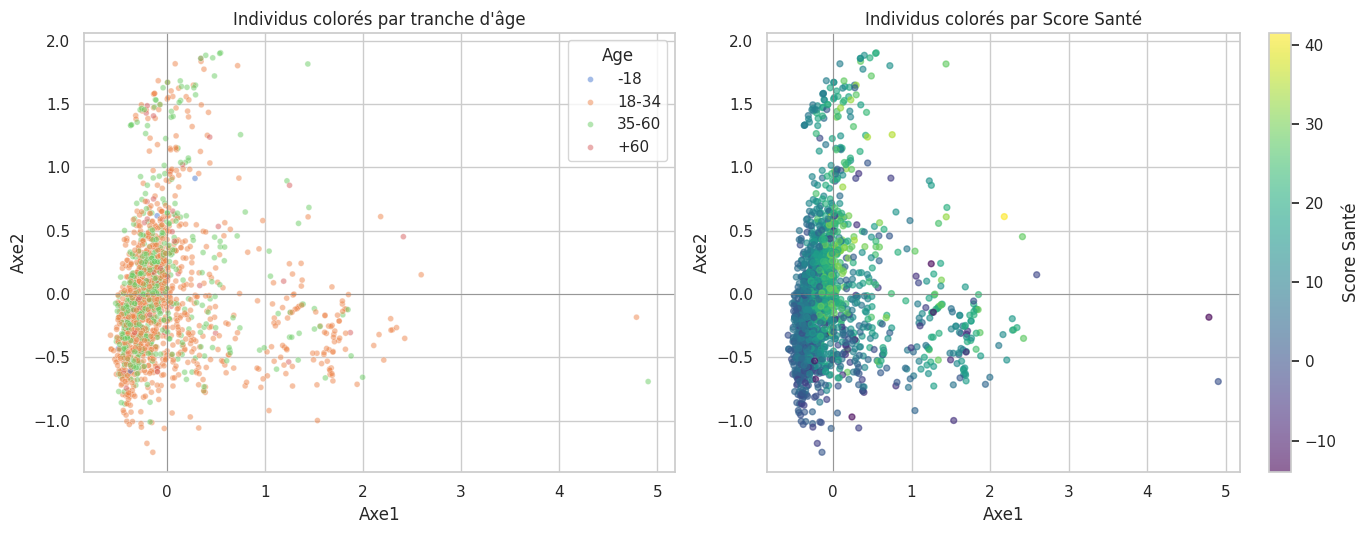

In [6]:
rc = mca.row_coordinates(X).rename(columns={0: "Axe1", 1: "Axe2"})
proj = pd.concat([rc[["Axe1", "Axe2"]], df[["Age", "Score_Sante"]].reset_index(drop=True)], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.scatterplot(data=proj, x="Axe1", y="Axe2", hue="Age",
                hue_order=["-18", "18-34", "35-60", "+60"], alpha=0.5, s=18, ax=axes[0])
axes[0].set_title("Individus colorés par tranche d'âge")
sc = axes[1].scatter(proj["Axe1"], proj["Axe2"], c=proj["Score_Sante"], cmap="viridis", alpha=0.6, s=18)
axes[1].set_title("Individus colorés par Score Santé"); axes[1].set_xlabel("Axe1"); axes[1].set_ylabel("Axe2")
fig.colorbar(sc, ax=axes[1], label="Score Santé")
for a in axes:
    a.axhline(0, color="grey", lw=0.5); a.axvline(0, color="grey", lw=0.5)
fig.tight_layout()

On chiffre ces tendances par des corrélations de Spearman entre coordonnées et variables.

In [7]:
r1 = spearmanr(proj["Axe1"], proj["Score_Sante"]).statistic
r2 = spearmanr(proj["Axe2"], proj["Score_Sante"]).statistic
age2 = proj.groupby("Age", observed=True)["Axe2"].mean().reindex(["-18", "18-34", "35-60", "+60"]).round(2)
display(Markdown(f"- Corrélation **Axe 1 ↔ Score Santé** : ρ = {r1:.2f}\n"
                 f"- Corrélation **Axe 2 ↔ Score Santé** : ρ = {r2:.2f}\n"
                 f"- **Axe 2 moyen par âge** : {age2.to_dict()}"))

- Corrélation **Axe 1 ↔ Score Santé** : ρ = 0.44
- Corrélation **Axe 2 ↔ Score Santé** : ρ = 0.43
- **Axe 2 moyen par âge** : {'-18': 0.08, '18-34': -0.05, '35-60': 0.08, '+60': 0.17}

Deux enseignements. D'une part, les deux axes corrèlent modérément avec le Score Santé
(ρ ≈ 0,44) : l'espace de consommation et le score racontent des choses voisines mais pas
identiques. D'autre part, **l'axe 2 croît avec l'âge** (les +60 ans sont les plus « carnés »
en fréquence), mais le nuage par âge reste **largement superposé** : aucune tranche d'âge
n'occupe une région propre.

## 7. Synthèse

**La structure de l'espace alimentaire.** Une fois l'inertie corrigée (Benzécri), deux
dimensions suffisent (≈ 62 %) :

- **Axe 1 — l'engagement** : oppose une petite minorité déclarant « ne jamais » consommer
  la plupart des aliments au reste des répondants. C'est d'abord un axe de
  non-consommation (et possiblement de style de réponse au questionnaire).
- **Axe 2 — l'intensité carnée** : sépare les gros consommateurs de viande et de poisson des
  plus modérés ; il augmente avec l'âge.

**Le point sociologique central.** Contrairement à l'hypothèse bourdieusienne forte, les
**variables socio-démographiques structurent faiblement** cet espace : les nuages par âge
ou par diplôme se recouvrent très largement, et l'axe principal tient surtout à des
réponses « Jamais ». Cela **converge avec le notebook 02** (la régression n'expliquait que
~9 % du Score Santé) : dans cet échantillon jeune et homogène, *ce qu'on mange* ne se déduit
guère de *qui l'on est* socialement.

La piste suivante n'est donc plus sociale mais **cognitive** : et si les différences se
jouaient dans les **croyances et connaissances** nutritionnelles ? C'est l'objet du
notebook 04.